In [13]:
import pandas as pd

df = pd.read_csv("data/cs-training.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [14]:
df.shape

(150000, 11)

In [15]:
df["SeriousDlqin2yrs"].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [16]:
df.isna().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [17]:
df["MonthlyIncome_missing"]=df["MonthlyIncome"].isna().astype(int)
df.groupby("MonthlyIncome_missing") ["SeriousDlqin2yrs"].mean()

MonthlyIncome_missing
0    0.069486
1    0.056137
Name: SeriousDlqin2yrs, dtype: float64

In [18]:
df["MonthlyIncome"].isna().mean()

np.float64(0.19820666666666667)

In [19]:
median_income=df["MonthlyIncome"].mean()
df["MonthlyIncome"]=df["MonthlyIncome"].fillna(median_income)

In [20]:
df["MonthlyIncome"].isna().sum()

np.int64(0)

In [21]:
df.corr(numeric_only=True)["SeriousDlqin2yrs"].sort_values(ascending=False)

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.018002
MonthlyIncome_missing                  -0.021308
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64

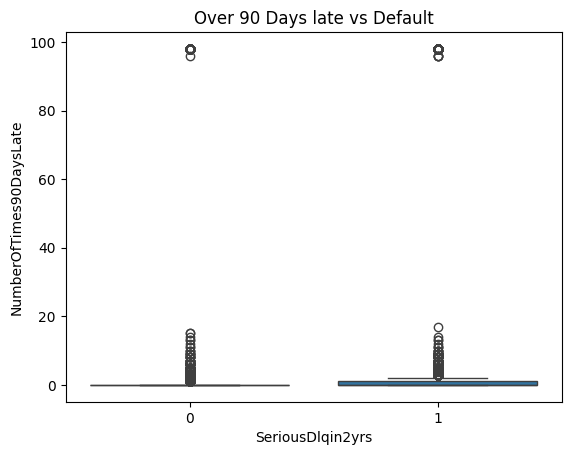

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="SeriousDlqin2yrs", y="NumberOfTimes90DaysLate",data=df)
plt.title("Over 90 Days late vs Default")
plt.show()

In [23]:
df.groupby("SeriousDlqin2yrs")["NumberOfTimes90DaysLate"].describe()

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,,,,,,,,
0,139974.0,0.135225,2.909088,0.0,0.0,0.0,0.0,98.0
1,10026.0,2.091362,11.762760,0.0,0.0,0.0,1.0,98.0


In [24]:
late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for c in late_cols:
    df[c] = df[c].clip(lower=0, upper=10)

# Revolving utilization should typically be 0-1, but can exceed 1; cap at 1.5 for stability
df["RevolvingUtilizationOfUnsecuredLines"] = df["RevolvingUtilizationOfUnsecuredLines"].clip(lower=0, upper=1.5)

# DebtRatio can be extreme; cap at 5 (you can justify as "extreme leverage/outliers")
df["DebtRatio"] = df["DebtRatio"].clip(lower=0, upper=5)

df[late_cols + ["RevolvingUtilizationOfUnsecuredLines","DebtRatio"]].describe().T[["min","50%","max"]]


,min,50%,max
NumberOfTime30-59DaysPastDueNotWorse,0.0,0.000000,10.0
NumberOfTime60-89DaysPastDueNotWorse,0.0,0.000000,10.0
NumberOfTimes90DaysLate,0.0,0.000000,10.0
RevolvingUtilizationOfUnsecuredLines,0.0,0.154181,1.5
DebtRatio,0.0,0.366508,5.0


In [28]:
from sklearn.model_selection import train_test_split
target="SeriousDlqin2yrs"
X=df.drop(columns=[target])
y=df[target]
X_train, X_test, y_train, y_test=train_test_split(
X,y, test_size=0.2 , random_state=42 , stratify=y
)

X_train.shape, X_test.shape

((120000, 11), (30000, 11))

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

log_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [32]:
from sklearn.metrics import roc_auc_score

proba_test = log_reg.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, proba_test)

roc

0.858981052459047

In [33]:
from sklearn.metrics import average_precision_score, confusion_matrix, classification_report

pr_auc = average_precision_score(y_test, proba_test)
pred_05 = (proba_test >= 0.5).astype(int)

print("ROC-AUC:", roc)
print("PR-AUC:", pr_auc)
print("Confusion matrix @0.5:\n", confusion_matrix(y_test, pred_05))
print("\nReport @0.5:\n", classification_report(y_test, pred_05, digits=3))

ROC-AUC: 0.858981052459047
PR-AUC: 0.38069537282575716
Confusion matrix @0.5:
 [[22497  5498]
 [  500  1505]]

Report @0.5:
               precision    recall  f1-score   support

           0      0.978     0.804     0.882     27995
           1      0.215     0.751     0.334      2005

    accuracy                          0.800     30000
   macro avg      0.597     0.777     0.608     30000
weighted avg      0.927     0.800     0.846     30000

